In [1]:
import IPython.display
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.visualization
import named_arrays as na
import ctis

In [2]:
velocity = na.linspace(-300, 300, axis="wavelength", num=21) * u.km / u.s

In [3]:
wavelength_rest = 171 * u.AA

In [4]:
doppler = u.doppler_optical(wavelength_rest)

In [5]:
wavelength = velocity.to(u.AA, equivalencies=doppler)

In [6]:
position_scene = na.Cartesian2dVectorLinearSpace(
    start=-10 * u.arcsec,
    stop=10 * u.arcsec,
    axis=na.Cartesian2dVectorArray("scene_x", "scene_y"),
    num=na.Cartesian2dVectorArray(64, 64),
)

In [7]:
position_sensor = na.Cartesian2dVectorArray(
    x=na.arange(0, 64, axis="sensor_x") * u.pix,
    y=na.arange(0, 64, axis="sensor_y") * u.pix,
)

In [8]:
coordinates_scene = na.SpectralPositionalVectorArray(velocity, position_scene)
coordinates_sensor = na.SpectralPositionalVectorArray(velocity, position_sensor)

In [9]:
instrument = ctis.instruments.IdealInstrument(
    area_effective=1 * u.cm**2,
    timedelta_exposure=10 * u.s,
    plate_scale=.4 * u.arcsec / u.pix,
    dispersion=10 * u.km / u.s / u.pix,
    angle=na.linspace(0, 360, num=36, axis="channel", endpoint=False) * u.deg,
    wavelength_ref=0 * u.km / u.s,
    position_ref=32 * u.pix,
    coordinates_scene=coordinates_scene,
    coordinates_sensor=coordinates_sensor,
    axis_wavelength="wavelength",
    axis_scene_xy=("scene_x", "scene_y"),
    axis_sensor_xy=("sensor_x", "sensor_y"),
)

In [10]:
center = na.SpectralPositionalVectorArray(
    wavelength=na.ScalarArray([-100, 0, 100] * u.km / u.s, axes="g"),
    position=na.Cartesian2dVectorArray(
        x=0 * u.arcsec,
        y=na.ScalarArray([-7, 0, 7] * u.arcsec, axes="g"),
    )
)
width = na.SpectralPositionalVectorArray(
    wavelength=na.ScalarArray([50, 100, 75] * u.km / u.s, axes="g"),
    position=na.ScalarArray([1, 1, 1] * u.arcsec, axes="g"),
)
amplitude = 1 / np.sqrt(2 * np.pi) / width
radiance = amplitude * np.exp(-np.square(((coordinates_scene - center) / width)) / 2)
radiance = radiance.wavelength * radiance.position.x * radiance.position.y
radiance = radiance * 1000 * u.erg / u.s / u.cm**2
radiance = radiance.cell_centers(("wavelength", "scene_x", "scene_y"))
radiance = radiance.sum("g")

scene = na.FunctionArray(
    inputs=coordinates_scene,
    outputs=radiance,
)

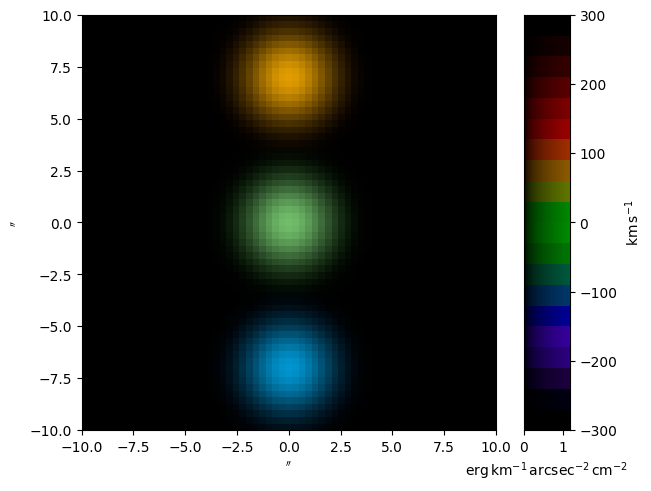

In [11]:
with astropy.visualization.quantity_support():
    fig, axs = plt.subplots(
        ncols=2,
        gridspec_kw=dict(width_ratios=[.9,.1]),
        constrained_layout=True,
    )
    colorbar = na.plt.rgbmesh(
        C=scene,
        axis_wavelength="wavelength",
        ax=axs[0],
        vmin=0,
        vmax=scene.outputs.max(),
    )
    na.plt.pcolormesh(
        C=colorbar,
        axis_rgb="wavelength",
        ax=axs[1],
    )
    axs[1].yaxis.tick_right()
    axs[1].yaxis.set_label_position("right")

In [12]:
image = instrument.image(scene.outputs)

In [13]:
with astropy.visualization.quantity_support():
    fig, axs = plt.subplots(
        ncols=2,
        gridspec_kw=dict(width_ratios=[.9,.1]),
        constrained_layout=True,
    )
    ax, cax = axs
    cax_twin = cax.twinx()
    ani, colorbar = na.plt.rgbmovie(
        instrument.angle,
        image.inputs.wavelength,
        image.inputs.position.x,
        image.inputs.position.y,
        C=image.outputs,
        axis_time="channel",
        axis_wavelength="wavelength",
        ax=ax,
        vmin=0,
        vmax=image.outputs.max(),
    )
    na.plt.pcolormesh(
        C=colorbar,
        axis_rgb="wavelength",
        ax=cax,
    )
    na.plt.pcolormesh(
        colorbar.inputs.x,
        colorbar.inputs.y.to(u.AA, equivalencies=doppler),
        C=colorbar.outputs,
        axis_rgb="wavelength",
        ax=cax_twin,
    )
    ax.set_xlabel(f"detector $x$ ({image.inputs.position.x.unit})")
    ax.set_ylabel(f"detector $y$ ({image.inputs.position.y.unit})")
    cax.xaxis.set_ticks_position("top")
    cax.xaxis.set_label_position("top")
    # cax.yaxis.tick_right()
    # cax.yaxis.set_label_position("right")

result = ani.to_jshtml(fps=10)
result = IPython.display.HTML(result)

plt.close(ani._fig)

result

In [14]:
image_avg = image.mean("wavelength")

In [15]:
backprojected = instrument.backproject(image_avg.outputs)

In [16]:
with astropy.visualization.quantity_support():
    fig, axs = plt.subplots(
        ncols=2,
        gridspec_kw=dict(width_ratios=[.9,.1]),
        constrained_layout=True,
    )
    ax, cax = axs
    ani, colorbar = na.plt.rgbmovie(
        instrument.angle,
        backprojected.inputs.wavelength,
        backprojected.inputs.position.x,
        backprojected.inputs.position.y,
        C=backprojected.outputs,
        axis_time="channel",
        axis_wavelength="wavelength",
        ax=ax,
        vmin=0,
        vmax=backprojected.outputs.max(),
    )
    na.plt.pcolormesh(
        C=colorbar,
        axis_rgb="wavelength",
        ax=cax,
    )
    ax.set_xlabel(f"detector $x$ ({image.inputs.position.x.unit})")
    ax.set_ylabel(f"detector $y$ ({image.inputs.position.y.unit})")
    cax.xaxis.set_ticks_position("top")
    cax.xaxis.set_label_position("top")
    cax.yaxis.tick_right()
    cax.yaxis.set_label_position("right")

result = ani.to_jshtml(fps=10)
result = IPython.display.HTML(result)

plt.close(ani._fig)

result